In [1]:
import pandas as pd

data = pd.read_csv('epl_2014_2025_team_matches.csv')
data.head()
luck_all = data.groupby(['team','season'])[['pts','xpts']].sum()

luck_all['luck'] = luck_all['pts'] - luck_all['xpts']
luck_all['luck_adj'] = luck_all["luck"] - luck_all.groupby('season')['luck'].transform('mean') #correction of luck using mean 
print(luck_all)
luck_all = luck_all.reset_index()

print(luck_all.shape) 

                                pts     xpts     luck   luck_adj
team                    season                                  
Arsenal                 2014     75  75.1740  -0.1740  -0.274485
                        2015     71  77.0087  -6.0087  -5.254740
                        2016     75  62.1195  12.8805  12.590505
                        2017     63  65.8991  -2.8991  -2.311815
                        2018     70  58.9713  11.0287  10.370040
...                             ...      ...      ...        ...
Wolverhampton Wanderers 2021     51  40.5351  10.4649  10.820835
                        2022     41  35.0081   5.9919   6.196905
                        2023     46  39.7876   6.2124   6.518265
                        2024     42  41.4533   0.5467   1.191455
                        2025     20  35.4384 -15.4384 -14.445410

[240 rows x 4 columns]
(240, 6)


In [2]:
luck_all["season"] = luck_all["season"].astype(int)   # για να δουλέψει το "- 1"

next_season = luck_all[["team", "season", "xpts", "luck_adj"]].copy()
next_season["season"] = next_season["season"] - 1
next_season = next_season.rename(columns={"xpts": "xpts_next", "luck_adj": "luck_next"})

pairs = luck_all.merge(next_season, on=['team', 'season'])
print(pairs.shape)
print(pairs.head())
print(luck_all.groupby("season")["luck_adj"].mean().round(2))

(187, 8)
      team  season  pts     xpts     luck   luck_adj  xpts_next  luck_next
0  Arsenal    2014   75  75.1740  -0.1740  -0.274485    77.0087  -5.254740
1  Arsenal    2015   71  77.0087  -6.0087  -5.254740    62.1195  12.590505
2  Arsenal    2016   75  62.1195  12.8805  12.590505    65.8991  -2.311815
3  Arsenal    2017   63  65.8991  -2.8991  -2.311815    58.9713  10.370040
4  Arsenal    2018   70  58.9713  11.0287  10.370040    50.1471   6.242785
season
2014   -0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
2022    0.0
2023   -0.0
2024   -0.0
2025   -0.0
Name: luck_adj, dtype: float64


In [28]:
r_luck = pairs["luck_adj"].corr(pairs["luck_next"])
r_quality = pairs["xpts"].corr(pairs["xpts_next"])

print("Luck → next season luck:", round(r_luck, 2))
print("Quality → next season quality:", round(r_quality, 2))

Luck → next season luck: 0.11
Quality → next season quality: 0.76


In [4]:
from scipy.stats import pearsonr
print(pearsonr(pairs["luck_adj"], pairs["luck_next"]))

PearsonRResult(statistic=np.float64(0.10858039441578554), pvalue=np.float64(0.13907734664208432))


In [5]:
print(pearsonr(pairs["xpts"], pairs["xpts_next"]))

PearsonRResult(statistic=np.float64(0.7603539876043646), pvalue=np.float64(1.6342472822199173e-36))


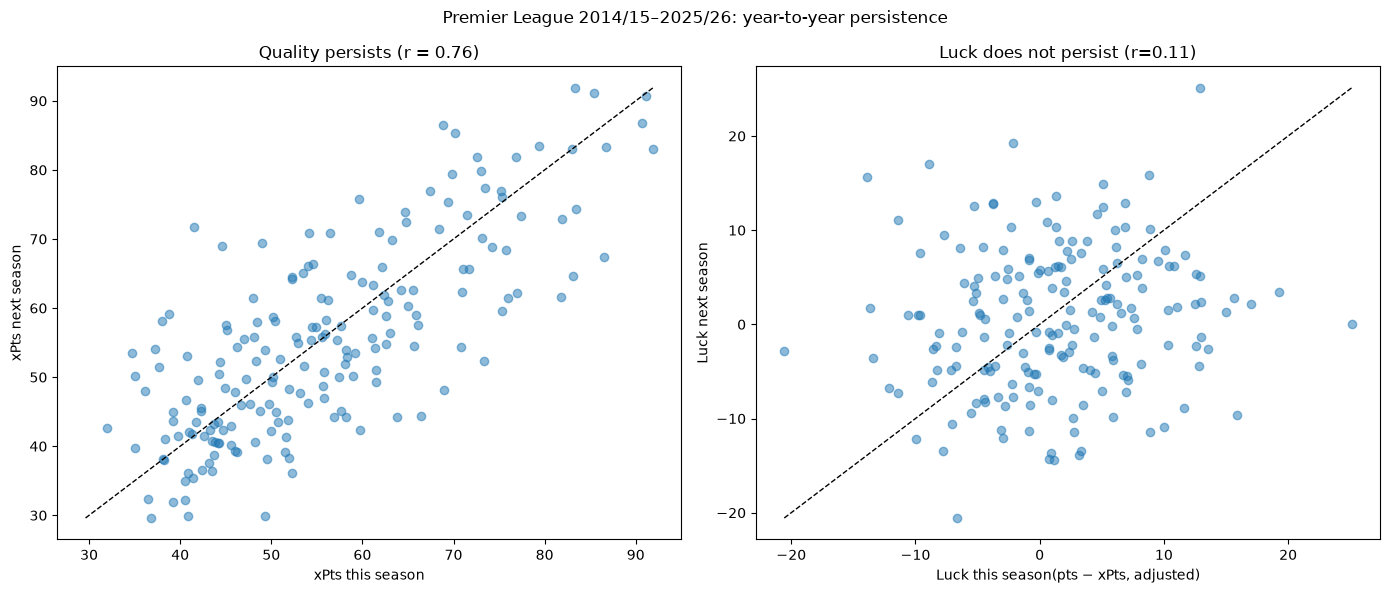

In [27]:
import matplotlib.pyplot as plt
r_quality = pairs['xpts'].corr(pairs['xpts_next'])
r_luck = pairs['luck_adj'].corr(pairs['luck_next'])


fig , (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))

#left we show quality
ax1.scatter(pairs["xpts"], pairs['xpts_next'], alpha =0.5)

lo = pairs[["xpts", "xpts_next"]].min().min()
hi = pairs[["xpts", "xpts_next"]].max().max()
ax1.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
ax1.set_title(f"Quality persists (r = {r_quality:.2f})")

ax1.set_xlabel("xPts this season")
ax1.set_ylabel("xPts next season")

#right we show luck
ax2.scatter(pairs["luck_adj"],pairs['luck_next'], alpha=0.5)
lo=pairs[['luck_adj',"luck_next"]].min().min()
hi=pairs[["luck_adj", 'luck_next']].max().max()

ax2.plot([lo,hi],[lo,hi],color="black",linestyle='--', linewidth=1)
ax2.set_title(f"Luck does not persist (r={r_luck:.2f})")

ax2.set_xlabel("Luck this season(pts − xPts, adjusted)")
ax2.set_ylabel("Luck next season")


fig.suptitle("Premier League 2014/15–2025/26: year-to-year persistence")
plt.tight_layout()
plt.savefig("persistence.png", dpi=150)
plt.show()